In [1]:
import pandas as pd
import numpy as np
import os 
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from tqdm import tqdm
from scipy.stats import chi2
import matplotlib.pyplot as plt

### Loading and preparing the data

In [2]:
MAIN_DIR = "/home/joan/Desktop/PROJECTS/Glioblastomas/"
RESULTS = f"{MAIN_DIR}/RESULTS-GBM_4-cohorts_Tissues"
os.makedirs(f"{RESULTS}", exist_ok=True)
os.makedirs(f"{RESULTS}/Forest-plots_Cox-models_complete-subset", exist_ok=True)

daysXmonth = 365/12
voxel_size = (0.5**3) * (1/1000) # 0.5 (mm³/voxel) X 0.001 (cm³/mm³)   

In [3]:
def bootstrap_cindex(
        model, 
        data, 
        features,
        status="status",
        survival="OS (days) - corrected",
        n_bootstrap=1000, 
        alpha_CI=0.05,
        seed=42
    ):
    """Return (mean, lower 95% CI, upper 95% CI) of bootstrapped C-index."""
    rng = np.random.default_rng(seed)
    cindex_boot = []
    preds = model.predict_partial_hazard(data[features])
    for ib in tqdm(range(n_bootstrap), desc="Bootsrapping procedure"):
        idx = rng.integers(0, len(data), len(data))
        cidx = concordance_index(data[survival].values[idx], -preds.values[idx], data[status].values[idx])
        cindex_boot.append(cidx)
    cindex_boot = np.array(cindex_boot)
    lower = np.percentile(cindex_boot, 100 * (alpha_CI / 2))
    upper = np.percentile(cindex_boot, 100 * (1 - alpha_CI / 2))

    return (cindex_boot.mean(), lower, upper), cindex_boot


def llr_pvalue(ll_full, ll_reduced, df_diff):
    """Likelihood-ratio test p-value. df_diff = difference in free parameters."""
    lr_stat = 2 * (ll_full - ll_reduced)
    return chi2.sf(lr_stat, df=df_diff)


def print_model_summary(label, model, cindex_train, ci_boot):
    """Pretty-print log-HRs, HRs, p-values and CIs for one model."""
    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")

    summary = model.summary  # lifelines DataFrame
    display_cols = ["exp(coef)", "coef", "exp(coef) lower 95%",
                    "exp(coef) upper 95%", "p"]
    rename = {
        "coef":                  "log-HR",
        "exp(coef)":             "HR",
        "exp(coef) lower 95%":  "HR CI lower",
        "exp(coef) upper 95%":  "HR CI upper",
        "p":                     "p-value",
    }
    out = summary[display_cols].rename(columns=rename)
    out["sig"] = out["p-value"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    )

    with pd.option_context("display.float_format", "{:.8f}".format):
        print(out.to_string())

    print(f"\n  Train C-index : {cindex_train:.4f}")
    print(f"  Bootstrap C-index : {ci_boot[0]:.4f}  "
          f"(95% CI {ci_boot[1]:.4f} – {ci_boot[2]:.4f})")
    print(f"  Log-likelihood    : {model.log_likelihood_:.4f}")
    print(f"  AIC    : {model.AIC_partial_:.4f}")

In [4]:
data = pd.read_csv(f"{RESULTS}/data-clinical_TD-tissues_4-cohorts.csv", sep=",")
data["Enhancing size (cm3)"] = voxel_size * data["Enhancing size (voxels)"]

The following cell optionally discards patients without complete data availability. Comparing models fit with different data points might render AIC and log-likelihood comparissons invalid. However, the number of incomplete points is so small that it doesn't matter in practica.

In [5]:
data.dropna(subset=["Enhancing size (cm3)", "Whole lesion TDMap", "Enhancing TDMap"], inplace=True)

### Volume or L-TDI?

In [31]:
data2compare = data[["OS (days) - corrected", "status", "Enhancing size (cm3)", "Whole lesion TDMap"]].copy().dropna()

cph_ = CoxPHFitter(baseline_estimation_method="breslow")
cph_.fit(data2compare, duration_col="OS (days) - corrected", event_col="status")
cindex_ = cph_.score(data2compare, scoring_method="concordance_index")
ll_ = cph_.log_likelihood_
aic_ = cph_.AIC_partial_
ci_boot_, dist_boot_ = bootstrap_cindex(cph_, data2compare, ["OS (days) - corrected", "status", "Enhancing size (cm3)", "Whole lesion TDMap"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 1 (age + sex + W.LTDI N={len(data2compare)})", cph_, cindex_, ci_boot_)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 296.91it/s]


════════════════════════════════════════════════════════════
  Model 1 (age + sex + W.LTDI N=995)
════════════════════════════════════════════════════════════
                             HR     log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                           
Enhancing size (cm3) 1.00192809 0.00192624   0.99736258   1.00651451 0.40844496     
Whole lesion TDMap   1.09368606 0.08955370   1.04050751   1.14958248 0.00042936  ***

  Train C-index : 0.5681
  Bootstrap C-index : 0.5680  (95% CI 0.5448 – 0.5895)
  Log-likelihood    : -4774.3401
  AIC    : 9552.6801


In [32]:
data2compare = data[["OS (days) - corrected", "status", "Enhancing size (cm3)", "Enhancing TDMap"]].copy().dropna()

cph__ = CoxPHFitter(baseline_estimation_method="breslow")
cph__.fit(data2compare, duration_col="OS (days) - corrected", event_col="status")
cindex__ = cph__.score(data2compare, scoring_method="concordance_index")
ll__ = cph__.log_likelihood_
aic__ = cph__.AIC_partial_
ci_boot__, dist_boot__ = bootstrap_cindex(cph__, data2compare, ["OS (days) - corrected", "status", "Enhancing size (cm3)", "Enhancing TDMap"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 1 (age + sex + W.LTDI N={len(data2compare)})", cph__, cindex__, ci_boot__)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 297.40it/s]


════════════════════════════════════════════════════════════
  Model 1 (age + sex + W.LTDI N=995)
════════════════════════════════════════════════════════════
                             HR     log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                           
Enhancing size (cm3) 1.00646168 0.00644089   1.00288377   1.01005235 0.00039294  ***
Enhancing TDMap      1.00315783 0.00315286   1.00192087   1.00439632 0.00000055  ***

  Train C-index : 0.5737
  Bootstrap C-index : 0.5737  (95% CI 0.5514 – 0.5959)
  Log-likelihood    : -4768.4544
  AIC    : 9540.9088


In [33]:
data2compare = data[["OS (days) - corrected", "status", "Enhancing TDMap", "Whole lesion TDMap"]].copy().dropna()

cph___ = CoxPHFitter(baseline_estimation_method="breslow")
cph___.fit(data2compare, duration_col="OS (days) - corrected", event_col="status")
cindex___ = cph___.score(data2compare, scoring_method="concordance_index")
ll___ = cph___.log_likelihood_
aic___ = cph___.AIC_partial_
ci_boot___, dist_boot___ = bootstrap_cindex(cph___, data2compare, ["OS (days) - corrected", "status", "Enhancing TDMap", "Whole lesion TDMap"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 1 (age + sex + W.LTDI N={len(data2compare)})", cph___, cindex___, ci_boot___)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 297.08it/s]


════════════════════════════════════════════════════════════
  Model 1 (age + sex + W.LTDI N=995)
════════════════════════════════════════════════════════════
                           HR     log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                         
Enhancing TDMap    1.00261468 0.00261127   1.00134972   1.00388124 0.00005035  ***
Whole lesion TDMap 1.08640304 0.08287227   1.04243544   1.13222510 0.00008436  ***

  Train C-index : 0.5796
  Bootstrap C-index : 0.5796  (95% CI 0.5574 – 0.6012)
  Log-likelihood    : -4766.8043
  AIC    : 9537.6086


### Pre-surgical features

In [6]:
ltdi_whole_pre = data[["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap"]].copy().dropna()

cph_1 = CoxPHFitter(baseline_estimation_method="breslow")
cph_1.fit(ltdi_whole_pre, duration_col="OS (days) - corrected", event_col="status")
cindex_1 = cph_1.score(ltdi_whole_pre, scoring_method="concordance_index")
ll_1 = cph_1.log_likelihood_
aic_1 = cph_1.AIC_partial_
ci_boot_1, dist_boot_1 = bootstrap_cindex(cph_1, ltdi_whole_pre, ["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 1 (age + sex + W.LTDI N={len(ltdi_whole_pre)})", cph_1, cindex_1, ci_boot_1)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 296.46it/s]


════════════════════════════════════════════════════════════
  Model 1 (age + sex + W.LTDI N=995)
════════════════════════════════════════════════════════════
                           HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                          
age                1.02573055  0.02540509   1.01913401   1.03236978 0.00000000  ***
sex                0.93648543 -0.06562132   0.81323378   1.07841679 0.36207388     
Whole lesion TDMap 1.09352582  0.08940717   1.05117375   1.13758426 0.00000915  ***

  Train C-index : 0.6284
  Bootstrap C-index : 0.6284  (95% CI 0.6075 – 0.6495)
  Log-likelihood    : -4743.2629
  AIC    : 9492.5258


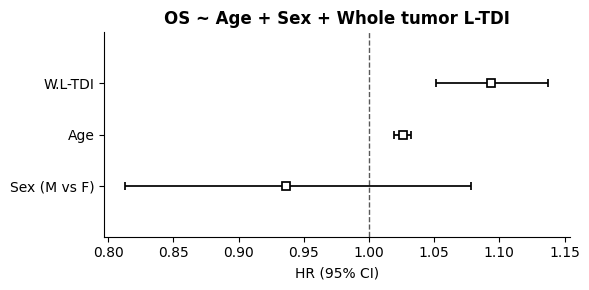

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_1.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["Sex (M vs F)", "Age", "W.L-TDI"])
ax.set_ylim([-1, 3])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + Whole tumor L-TDI", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Presurgical_WLTDI.svg", dpi=200)

In [8]:
ltdi_enh_pre = data[["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap"]].copy().dropna()

cph_2 = CoxPHFitter(baseline_estimation_method="breslow")
cph_2.fit(ltdi_enh_pre, duration_col="OS (days) - corrected", event_col="status")
cindex_2 = cph_2.score(ltdi_enh_pre, scoring_method="concordance_index")
ll_2 = cph_2.log_likelihood_
aic_2 = cph_2.AIC_partial_
ci_boot_2, dist_boot_2 = bootstrap_cindex(cph_2, ltdi_enh_pre, ["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 2 (age + sex + E.LTDI N={len(ltdi_enh_pre)})", cph_2, cindex_2, ci_boot_2)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 295.24it/s]


════════════════════════════════════════════════════════════
  Model 2 (age + sex + E.LTDI N=995)
════════════════════════════════════════════════════════════
                        HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                       
age             1.02711089  0.02674990   1.02048982   1.03377493 0.00000000  ***
sex             0.95000577 -0.05128722   0.82509861   1.09382194 0.47578892     
Enhancing TDMap 1.00325299  0.00324771   1.00203741   1.00447004 0.00000015  ***

  Train C-index : 0.6258
  Bootstrap C-index : 0.6257  (95% CI 0.6042 – 0.6475)
  Log-likelihood    : -4739.9185
  AIC    : 9485.8370


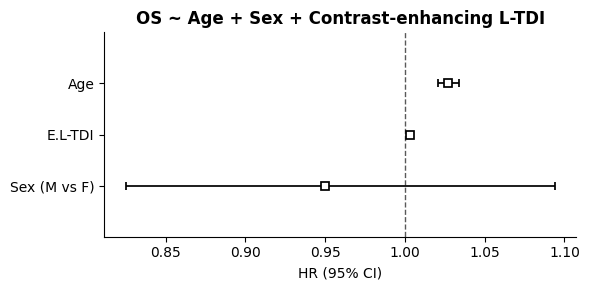

In [9]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_2.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["Sex (M vs F)", "E.L-TDI", "Age"])
ax.set_ylim([-1, 3])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + Contrast-enhancing L-TDI", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Presurgical_ELTDI.svg", dpi=200)

In [10]:
vol_enh_pre = data[["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)"]].copy().dropna()

cph_3 = CoxPHFitter(baseline_estimation_method="breslow")
cph_3.fit(vol_enh_pre, duration_col="OS (days) - corrected", event_col="status")
cindex_3 = cph_3.score(vol_enh_pre, scoring_method="concordance_index")
ll_3 = cph_3.log_likelihood_
aic_3 = cph_3.AIC_partial_
ci_boot_3, dist_boot_3 = bootstrap_cindex(cph_3, vol_enh_pre, ["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 3 (age + sex + E.size N={len(vol_enh_pre)})", cph_3, cindex_3, ci_boot_3)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 295.80it/s]


════════════════════════════════════════════════════════════
  Model 3 (age + sex + E.size N=995)
════════════════════════════════════════════════════════════
                             HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                            
age                  1.02602803  0.02569507   1.01942322   1.03267564 0.00000000  ***
sex                  0.93925781 -0.06266528   0.81564854   1.08159972 0.38407161     
Enhancing size (cm3) 1.00564423  0.00562837   1.00211433   1.00918657 0.00170542   **

  Train C-index : 0.6199
  Bootstrap C-index : 0.6198  (95% CI 0.5985 – 0.6412)
  Log-likelihood    : -4748.3614
  AIC    : 9502.7228


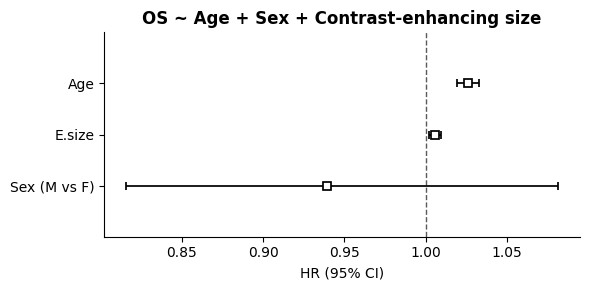

In [11]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_3.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["Sex (M vs F)", "E.size", "Age"])
ax.set_ylim([-1, 3])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + Contrast-enhancing size", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Presurgical_Esize.svg", dpi=200)

In [12]:
pre = data[["OS (days) - corrected", "status", "age", "sex"]].copy().dropna()

cph_4 = CoxPHFitter(baseline_estimation_method="breslow")
cph_4.fit(pre, duration_col="OS (days) - corrected", event_col="status")
cindex_4 = cph_4.score(pre, scoring_method="concordance_index")
ll_4 = cph_4.log_likelihood_
aic_4 = cph_4.AIC_partial_
ci_boot_4, dist_boot_4 = bootstrap_cindex(cph_4, pre, ["OS (days) - corrected", "status", "age", "sex"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 4 (age + sex + mgmt + eor N={len(pre)})", cph_4, cindex_4, ci_boot_4)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 307.21it/s]


════════════════════════════════════════════════════════════
  Model 4 (age + sex + mgmt + eor N=995)
════════════════════════════════════════════════════════════
                  HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                 
age       1.02693514  0.02657877   1.02034514   1.03356770 0.00000000  ***
sex       0.94789061 -0.05351617   0.82327621   1.09136716 0.45676946     

  Train C-index : 0.6149
  Bootstrap C-index : 0.6149  (95% CI 0.5925 – 0.6372)
  Log-likelihood    : -4753.1142
  AIC    : 9510.2285


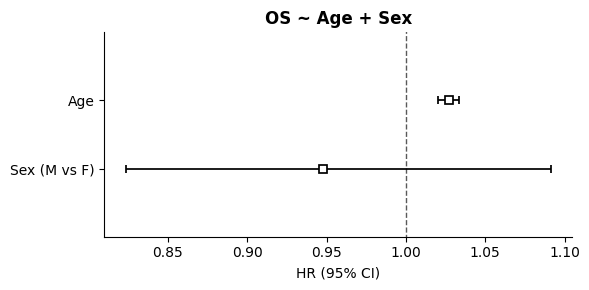

In [13]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_4.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["Sex (M vs F)", "Age"])
ax.set_ylim([-1, 2])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Presurgical_base.svg", dpi=200)

In [14]:
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex, E.LTDI) = {aic_1 - aic_2}")
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex, E.size) = {aic_1 - aic_3}")
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex) = {aic_1 - aic_4}")
print(f"AIC(age, sex, E.LTDI) - AIC(age, sex, E.size) = {aic_2 - aic_3}")
print(f"AIC(age, sex, E.LTDI) - AIC(age, sex) = {aic_2- aic_4}")
print(f"AIC(age, sex, E.size) - AIC(age, sex) = {aic_3 - aic_4}")

AIC(age, sex, W.LTDI) - AIC(age, sex, E.LTDI) = 6.688824679413301
AIC(age, sex, W.LTDI) - AIC(age, sex, E.size) = -10.196935762107387
AIC(age, sex, W.LTDI) - AIC(age, sex) = -17.702649085631492
AIC(age, sex, E.LTDI) - AIC(age, sex, E.size) = -16.885760441520688
AIC(age, sex, E.LTDI) - AIC(age, sex) = -24.391473765044793
AIC(age, sex, E.size) - AIC(age, sex) = -7.505713323524105


In [15]:
print(f"LLR(age, sex, W.LTDI; age, sex) = {llr_pvalue(ll_1, ll_4, df_diff=1)}")
print(f"LLR(age, sex, E.LTDI; age, sex) = {llr_pvalue(ll_2, ll_4, df_diff=1)}")
print(f"LLR(age, sex, E.size; age, sex) = {llr_pvalue(ll_3, ll_4, df_diff=1)}")

LLR(age, sex, W.LTDI; age, sex) = 9.047585752198385e-06
LLR(age, sex, E.LTDI; age, sex) = 2.787683156486934e-07
LLR(age, sex, E.size; age, sex) = 0.0020483311531555278


### Post-surgical features

In [16]:
ltdi_whole_post = data[["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap", "mgmt", "eor"]].copy().dropna()

cph_1 = CoxPHFitter(baseline_estimation_method="breslow")
cph_1.fit(ltdi_whole_post, duration_col="OS (days) - corrected", event_col="status")
cindex_1 = cph_1.score(ltdi_whole_post, scoring_method="concordance_index")
ll_1 = cph_1.log_likelihood_
aic_1 = cph_1.AIC_partial_
ci_boot_1, dist_boot_1 = bootstrap_cindex(cph_1, ltdi_whole_post, ["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap", "mgmt", "eor"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 1 (age + sex + mgmt + eor +  W.LTDI N={len(ltdi_whole_post)})", cph_1, cindex_1, ci_boot_1)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:09<00:00, 517.19it/s]


════════════════════════════════════════════════════════════
  Model 1 (age + sex + mgmt + eor +  W.LTDI N=615)
════════════════════════════════════════════════════════════
                           HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                          
age                1.02586491  0.02553607   1.01693309   1.03487517 0.00000001  ***
sex                0.96283223 -0.03787610   0.79699619   1.16317482 0.69452546     
Whole lesion TDMap 1.07848515  0.07555741   1.02516058   1.13458343 0.00349544   **
mgmt               0.74742387 -0.29112282   0.67868721   0.82312210 0.00000000  ***
eor                0.57324233 -0.55644673   0.48539050   0.67699465 0.00000000  ***

  Train C-index : 0.6699
  Bootstrap C-index : 0.6700  (95% CI 0.6423 – 0.6973)
  Log-likelihood    : -2496.7090
  AIC    : 5003.4180


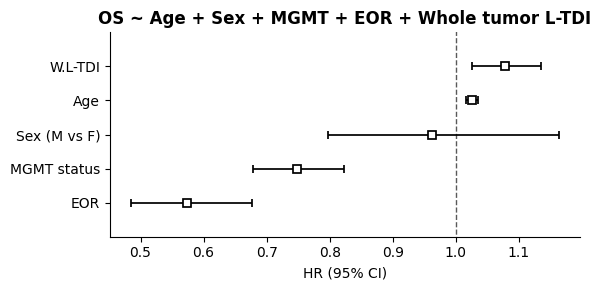

In [17]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_1.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["EOR", "MGMT status", "Sex (M vs F)", "Age", "W.L-TDI"])
ax.set_ylim([-1, 5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + MGMT + EOR + Whole tumor L-TDI", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Postsurgical_WLTDI.svg", dpi=200)

In [18]:
ltdi_enh_post = data[["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap", "mgmt", "eor"]].copy().dropna()

cph_2 = CoxPHFitter(baseline_estimation_method="breslow")
cph_2.fit(ltdi_enh_post, duration_col="OS (days) - corrected", event_col="status")
cindex_2 = cph_2.score(ltdi_enh_post, scoring_method="concordance_index")
ll_2 = cph_2.log_likelihood_
aic_2 = cph_2.AIC_partial_
ci_boot_2, dist_boot_2 = bootstrap_cindex(cph_2, ltdi_enh_post, ["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap", "mgmt", "eor"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 2 (age + sex + mgmt + eor +  E.LTDI N={len(ltdi_enh_post)})", cph_2, cindex_2, ci_boot_2)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:09<00:00, 515.59it/s]


════════════════════════════════════════════════════════════
  Model 2 (age + sex + mgmt + eor +  E.LTDI N=615)
════════════════════════════════════════════════════════════
                        HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                       
age             1.02723945  0.02687506   1.01832695   1.03622996 0.00000000  ***
sex             0.99178429 -0.00824964   0.82145216   1.19743563 0.93161892     
Enhancing TDMap 1.00272304  0.00271933   1.00110867   1.00434001 0.00094031  ***
mgmt            0.74119941 -0.29948558   0.67275528   0.81660685 0.00000000  ***
eor             0.57132856 -0.55979083   0.48387947   0.67458189 0.00000000  ***

  Train C-index : 0.6663
  Bootstrap C-index : 0.6664  (95% CI 0.6384 – 0.6937)
  Log-likelihood    : -2495.6198
  AIC    : 5001.2396


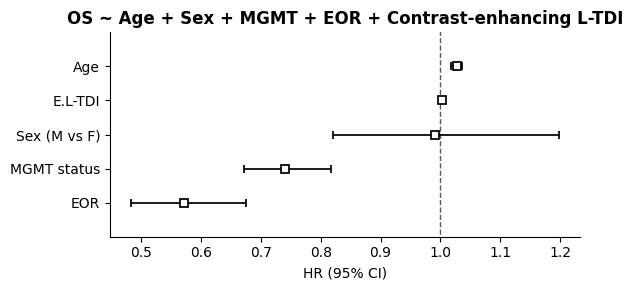

In [19]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_2.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["EOR", "MGMT status", "Sex (M vs F)", "E.L-TDI", "Age"])
ax.set_ylim([-1, 5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + MGMT + EOR + Contrast-enhancing L-TDI", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Postsurgical_ELTDI.svg", dpi=200)

In [20]:
vol_enh_post = data[["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)", "mgmt", "eor"]].copy().dropna()

cph_3 = CoxPHFitter(baseline_estimation_method="breslow")
cph_3.fit(vol_enh_post, duration_col="OS (days) - corrected", event_col="status")
cindex_3 = cph_3.score(vol_enh_post, scoring_method="concordance_index")
ll_3 = cph_3.log_likelihood_
aic_3 = cph_3.AIC_partial_
ci_boot_3, dist_boot_3 = bootstrap_cindex(cph_3, vol_enh_post, ["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)", "mgmt", "eor"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 3 (age + sex + mgmt + eor + E.size N={len(vol_enh_post)})", cph_3, cindex_3, ci_boot_3)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:09<00:00, 517.99it/s]


════════════════════════════════════════════════════════════
  Model 3 (age + sex + mgmt + eor + E.size N=615)
════════════════════════════════════════════════════════════
                             HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                            
age                  1.02560327  0.02528099   1.01668069   1.03460415 0.00000001  ***
sex                  0.95314472 -0.04798853   0.78769518   1.15334570 0.62178057     
Enhancing size (cm3) 1.00630773  0.00628792   1.00151318   1.01112523 0.00986611   **
mgmt                 0.74392186 -0.29581928   0.67550424   0.81926907 0.00000000  ***
eor                  0.54758143 -0.60224409   0.46419875   0.64594191 0.00000000  ***

  Train C-index : 0.6659
  Bootstrap C-index : 0.6659  (95% CI 0.6380 – 0.6934)
  Log-likelihood    : -2497.7459
  AIC    : 5005.4919


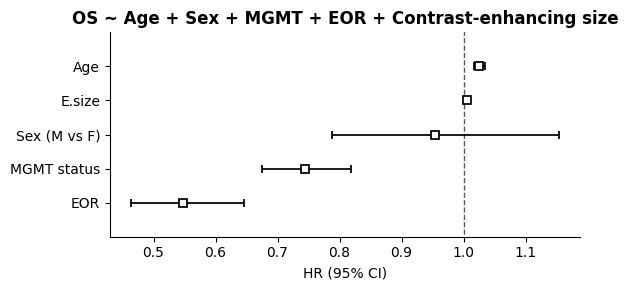

In [21]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_3.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["EOR", "MGMT status", "Sex (M vs F)", "E.size", "Age"])
ax.set_ylim([-1, 5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + MGMT + EOR + Contrast-enhancing size", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Postsurgical_Esize.svg", dpi=200)

In [22]:
post = data[["OS (days) - corrected", "status", "age", "sex", "mgmt", "eor"]].copy().dropna()

cph_4 = CoxPHFitter(baseline_estimation_method="breslow")
cph_4.fit(post, duration_col="OS (days) - corrected", event_col="status")
cindex_4 = cph_4.score(post, scoring_method="concordance_index")
ll_4 = cph_4.log_likelihood_
aic_4 = cph_4.AIC_partial_
ci_boot_4, dist_boot_4 = bootstrap_cindex(cph_4, post, ["OS (days) - corrected", "status", "age", "sex", "mgmt", "eor"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 4 (age + sex + mgmt + eor N={len(post)})", cph_4, cindex_4, ci_boot_4)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:09<00:00, 521.49it/s]


════════════════════════════════════════════════════════════
  Model 4 (age + sex + mgmt + eor N=615)
════════════════════════════════════════════════════════════
                  HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                 
age       1.02633000  0.02598933   1.01745581   1.03528160 0.00000000  ***
sex       0.99052790 -0.00951725   0.82056274   1.19569834 0.92106678     
mgmt      0.74741780 -0.29113095   0.67853502   0.82329333 0.00000000  ***
eor       0.54988634 -0.59804368   0.46664521   0.64797618 0.00000000  ***

  Train C-index : 0.6619
  Bootstrap C-index : 0.6620  (95% CI 0.6335 – 0.6896)
  Log-likelihood    : -2500.9574
  AIC    : 5009.9148


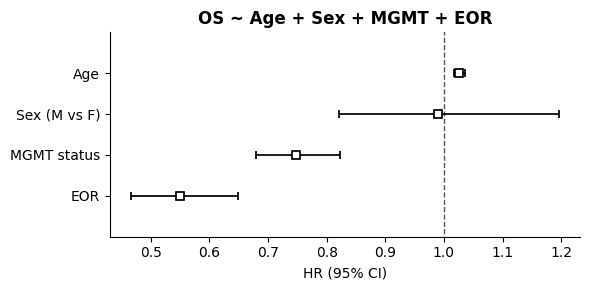

In [23]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_4.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["EOR", "MGMT status", "Sex (M vs F)", "Age"])
ax.set_ylim([-1, 4])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + MGMT + EOR", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Postsurgical_base.svg", dpi=200)

In [24]:
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex, E.LTDI) = {aic_1 - aic_2}")
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex, E.size) = {aic_1 - aic_3}")
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex) = {aic_1 - aic_4}")
print(f"AIC(age, sex, E.LTDI) - AIC(age, sex, E.size) = {aic_2 - aic_3}")
print(f"AIC(age, sex, E.LTDI) - AIC(age, sex) = {aic_2- aic_4}")
print(f"AIC(age, sex, E.size) - AIC(age, sex) = {aic_3 - aic_4}")

AIC(age, sex, W.LTDI) - AIC(age, sex, E.LTDI) = 2.178420587479195
AIC(age, sex, W.LTDI) - AIC(age, sex, E.size) = -2.0738245510037814
AIC(age, sex, W.LTDI) - AIC(age, sex) = -6.496762097436658
AIC(age, sex, E.LTDI) - AIC(age, sex, E.size) = -4.2522451384829765
AIC(age, sex, E.LTDI) - AIC(age, sex) = -8.675182684915853
AIC(age, sex, E.size) - AIC(age, sex) = -4.422937546432877


In [25]:
print(f"LLR(age, sex, W.LTDI; age, sex) = {llr_pvalue(ll_1, ll_4, df_diff=1)}")
print(f"LLR(age, sex, E.LTDI; age, sex) = {llr_pvalue(ll_2, ll_4, df_diff=1)}")
print(f"LLR(age, sex, E.size; age, sex) = {llr_pvalue(ll_3, ll_4, df_diff=1)}")

LLR(age, sex, W.LTDI; age, sex) = 0.0035577904671165463
LLR(age, sex, E.LTDI; age, sex) = 0.0010858246403359555
LLR(age, sex, E.size; age, sex) = 0.011265566345160622


# Cross-validating outcomes 

In [6]:
from lifelines import WeibullAFTFitter, LogLogisticAFTFitter

In [7]:
features2include = ["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap"]

for model, fitter in [("Cox", CoxPHFitter(baseline_estimation_method="breslow")), ("Weibull AFT", WeibullAFTFitter()), ("LogLog AFT", LogLogisticAFTFitter())]:
    for ch in [0,1,2,3]:
        data_ts = data.loc[data["cohort"]==ch].copy()[features2include]
        data_tr = data.loc[data["cohort"]!=ch].copy()[features2include]
        fitter.fit(data_tr, duration_col="OS (days) - corrected", event_col="status")
        print("COHORT", ch, "left-out")
        print(model, "train", fitter.score(data_tr, scoring_method="concordance_index"))
        print(model, "test", fitter.score(data_ts, scoring_method="concordance_index"))

        # MSE on uncensored test patients only
        events_ts = data_ts[data_ts["status"] == 1]
        predicted = fitter.predict_expectation(events_ts)
        actual = events_ts["OS (days) - corrected"]
        mse = np.mean((predicted.values - actual.values) ** 2)
        print(model, f"MSE (events only): {mse:.2f}")
        print('---')
    print("====")

COHORT 0 left-out
Cox train 0.6199778981698606
Cox test 0.6458633266148383
Cox MSE (events only): 342757.57
---
COHORT 1 left-out
Cox train 0.6466928697161872
Cox test 0.6138441698905944
Cox MSE (events only): 376205.73
---
COHORT 2 left-out
Cox train 0.6272533358244975
Cox test 0.6497961141760614
Cox MSE (events only): 469536.84
---
COHORT 3 left-out
Cox train 0.6285634925298192
Cox test 0.638121546961326
Cox MSE (events only): 171013.27
---
====
COHORT 0 left-out
Weibull AFT train 0.6202366513031994
Weibull AFT test 0.6459113158652462
Weibull AFT MSE (events only): 255077.22
---
COHORT 1 left-out
Weibull AFT train 0.6467049263340647
Weibull AFT test 0.6138774491451392
Weibull AFT MSE (events only): 394975.20
---
COHORT 2 left-out
Weibull AFT train 0.6274681987326203
Weibull AFT test 0.6488366514751739
Weibull AFT MSE (events only): 293963.30
---
COHORT 3 left-out
Weibull AFT train 0.6287077148244494
Weibull AFT test 0.6408839779005525
Weibull AFT MSE (events only): 145118.17
---
====

In [8]:
features2include = ["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap"]

for model, fitter in [("Cox", CoxPHFitter(baseline_estimation_method="breslow")), ("Weibull AFT", WeibullAFTFitter()), ("LogLog AFT", LogLogisticAFTFitter())]:
    for ch in [0,1,2,3]:
        data_ts = data.loc[data["cohort"]==ch].copy()[features2include]
        data_tr = data.loc[data["cohort"]!=ch].copy()[features2include]
        fitter.fit(data_tr, duration_col="OS (days) - corrected", event_col="status")
        print("COHORT", ch, "left-out")
        print(model, "train", fitter.score(data_tr, scoring_method="concordance_index"))
        print(model, "test", fitter.score(data_ts, scoring_method="concordance_index"))

        # MSE on uncensored test patients only
        events_ts = data_ts[data_ts["status"] == 1]
        predicted = fitter.predict_expectation(events_ts)
        actual = events_ts["OS (days) - corrected"]
        mse = np.mean((predicted.values - actual.values) ** 2)
        print(model, f"MSE (events only): {mse:.2f}")
        print('---')
    print("====")

COHORT 0 left-out
Cox train 0.6240640414005013
Cox test 0.6198291582685479
Cox MSE (events only): 363230.53
---
COHORT 1 left-out
Cox train 0.634696534928022
Cox test 0.6171720953450642
Cox MSE (events only): 366591.32
---
COHORT 2 left-out
Cox train 0.6274713126878104
Cox test 0.6310865915087551
Cox MSE (events only): 557033.34
---
COHORT 3 left-out
Cox train 0.6260235776743888
Cox test 0.6132596685082873
Cox MSE (events only): 195509.49
---
====
COHORT 0 left-out
Weibull AFT train 0.6237190372227164
Weibull AFT test 0.6204050292734428
Weibull AFT MSE (events only): 279906.95
---
COHORT 1 left-out
Weibull AFT train 0.6345277422777362
Weibull AFT test 0.6163650734223554
Weibull AFT MSE (events only): 378906.42
---
COHORT 2 left-out
Weibull AFT train 0.6271599171687919
Weibull AFT test 0.6286879347565364
Weibull AFT MSE (events only): 348075.85
---
COHORT 3 left-out
Weibull AFT train 0.6257217791689591
Weibull AFT test 0.6104972375690608
Weibull AFT MSE (events only): 169782.42
---
====

In [9]:
features2include = ["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)"]

for model, fitter in [("Cox", CoxPHFitter(baseline_estimation_method="breslow")), ("Weibull AFT", WeibullAFTFitter()), ("LogLog AFT", LogLogisticAFTFitter())]:
    for ch in [0,1,2,3]:
        data_ts = data.loc[data["cohort"]==ch].copy()[features2include]
        data_tr = data.loc[data["cohort"]!=ch].copy()[features2include]
        fitter.fit(data_tr, duration_col="OS (days) - corrected", event_col="status")
        print("COHORT", ch, "left-out")
        print(model, "train", fitter.score(data_tr, scoring_method="concordance_index"))
        print(model, "test", fitter.score(data_ts, scoring_method="concordance_index"))

        # MSE on uncensored test patients only
        events_ts = data_ts[data_ts["status"] == 1]
        predicted = fitter.predict_expectation(events_ts)
        actual = events_ts["OS (days) - corrected"]
        mse = np.mean((predicted.values - actual.values) ** 2)
        print(model, f"MSE (events only): {mse:.2f}")
        print('---')
    print("====")

COHORT 0 left-out
Cox train 0.6137031346863966
Cox test 0.6314425568672617
Cox MSE (events only): 335975.24
---
COHORT 1 left-out
Cox train 0.6376624629259
Cox test 0.6062648196680395
Cox MSE (events only): 371466.74
---
COHORT 2 left-out
Cox train 0.617709063166581
Cox test 0.6402014871671864
Cox MSE (events only): 393839.92
---
COHORT 3 left-out
Cox train 0.6193279241070236
Cox test 0.6712707182320442
Cox MSE (events only): 147830.20
---
====
COHORT 0 left-out
Weibull AFT train 0.613681571925285
Weibull AFT test 0.628659180343603
Weibull AFT MSE (events only): 255979.66
---
COHORT 1 left-out
Weibull AFT train 0.6376745195437776
Weibull AFT test 0.6064811348225799
Weibull AFT MSE (events only): 382843.87
---
COHORT 2 left-out
Weibull AFT train 0.6172388559328631
Weibull AFT test 0.6418805468937395
Weibull AFT MSE (events only): 258964.43
---
COHORT 3 left-out
Weibull AFT train 0.6187697304111404
Weibull AFT test 0.6712707182320442
Weibull AFT MSE (events only): 129856.92
---
====
COHO

In [10]:
features2include = ["OS (days) - corrected", "status", "age", "sex"]

for model, fitter in [("Cox", CoxPHFitter(baseline_estimation_method="breslow")), ("Weibull AFT", WeibullAFTFitter()), ("LogLog AFT", LogLogisticAFTFitter())]:
    for ch in [0,1,2,3]:
        data_ts = data.loc[data["cohort"]==ch].copy()[features2include]
        data_tr = data.loc[data["cohort"]!=ch].copy()[features2include]
        fitter.fit(data_tr, duration_col="OS (days) - corrected", event_col="status")
        print("COHORT", ch, "left-out")
        print(model, "train", fitter.score(data_tr, scoring_method="concordance_index"))
        print(model, "test", fitter.score(data_ts, scoring_method="concordance_index"))

        # MSE on uncensored test patients only
        events_ts = data_ts[data_ts["status"] == 1]
        predicted = fitter.predict_expectation(events_ts)
        actual = events_ts["OS (days) - corrected"]
        mse = np.mean((predicted.values - actual.values) ** 2)
        print(model, f"MSE (events only): {mse:.2f}")
        print('---')
    print("====")

COHORT 0 left-out
Cox train 0.6058030780841487
Cox test 0.6347778097706114
Cox MSE (events only): 361420.55
---
COHORT 1 left-out
Cox train 0.6323394661329604
Cox test 0.6026165813885769
Cox MSE (events only): 373860.37
---
COHORT 2 left-out
Cox train 0.6154732433400283
Cox test 0.6258095466538738
Cox MSE (events only): 470679.11
---
COHORT 3 left-out
Cox train 0.6146139916992057
Cox test 0.6229281767955801
Cox MSE (events only): 176521.83
---
====
COHORT 0 left-out
Weibull AFT train 0.6056467480660899
Weibull AFT test 0.6347778097706114
Weibull AFT MSE (events only): 269316.04
---
COHORT 1 left-out
Weibull AFT train 0.6323394661329604
Weibull AFT test 0.6025999417613045
Weibull AFT MSE (events only): 383876.88
---
COHORT 2 left-out
Weibull AFT train 0.6154639014744577
Weibull AFT test 0.6258095466538738
Weibull AFT MSE (events only): 302188.70
---
COHORT 3 left-out
Weibull AFT train 0.614731506161497
Weibull AFT test 0.6229281767955801
Weibull AFT MSE (events only): 151494.14
---
====